## Law of Large Numbers (LLN)

**The idea:** the more times you repeat a random experiment, the closer your observed
average gets to the **true** value.

Flip a coin 10 times — you might get 7 heads (70%), way off from 50%.
Flip it 10,000 times — you'll be very close to 50%.

**Why it matters:** this is why we can **trust averages from big samples.** Small samples
are noisy and unreliable; big samples settle down to the truth.

In [1]:
import random
random.seed(1)   # so we get the same result every run

flips_so_far = 0
heads_so_far = 0
running_fraction = []      # store the fraction of heads after each flip

for i in range(5000):
    flip = random.choice(["H", "T"])
    flips_so_far = flips_so_far + 1
    if flip == "H":
        heads_so_far = heads_so_far + 1
    running_fraction.append(heads_so_far / flips_so_far)

# look at how it settles down
for n in [10, 100, 1000, 5000]:
    print("after", n, "flips -> fraction heads =", round(running_fraction[n-1], 4))

print("\nIt wobbles early, then settles toward 0.5. That's the LLN.")

after 10 flips -> fraction heads = 0.5
after 100 flips -> fraction heads = 0.46
after 1000 flips -> fraction heads = 0.485
after 5000 flips -> fraction heads = 0.4934

It wobbles early, then settles toward 0.5. That's the LLN.


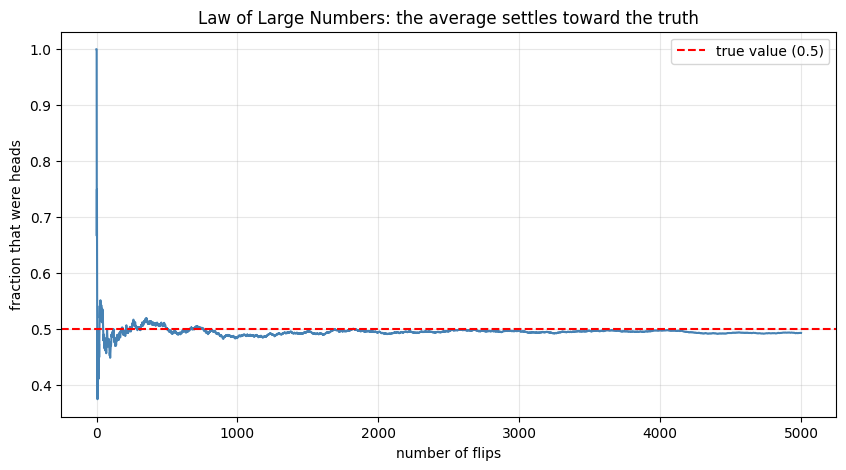

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(running_fraction, color="steelblue")
plt.axhline(0.5, color="red", linestyle="--", label="true value (0.5)")
plt.xlabel("number of flips")
plt.ylabel("fraction that were heads")
plt.title("Law of Large Numbers: the average settles toward the truth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Central Limit Theorem (CLT)

**The surprising one:** if you **average** a bunch of random things, those averages form a
**bell curve** — *no matter what shape the original data had.*

### The experiment
1. Roll 5 dice, take their **average**, write it down
2. Repeat thousands of times
3. Make a histogram of all those averages

A single die is **totally flat** (all six values equally likely). But the **averages** come
out bell-shaped!

### Why?
To get an extreme average like 1.0, **every** die must show a 1 — incredibly rare.
To get a middle average like 3.5, there are **hundreds** of ways (3+4, 1+6, 2+5...).

👉 **Extreme averages need everything to be extreme at once (rare). Middle averages happen
in countless ways (common).** So the middle piles up → a bell.

### Why this explains so much
Most real quantities are the result of **many small random effects added up** —
height (hundreds of genes + nutrition + sleep), measurement errors, exam scores.
**That's why the bell curve is everywhere.** It's not a coincidence; it's the CLT.

done -- now let's look at the shapes


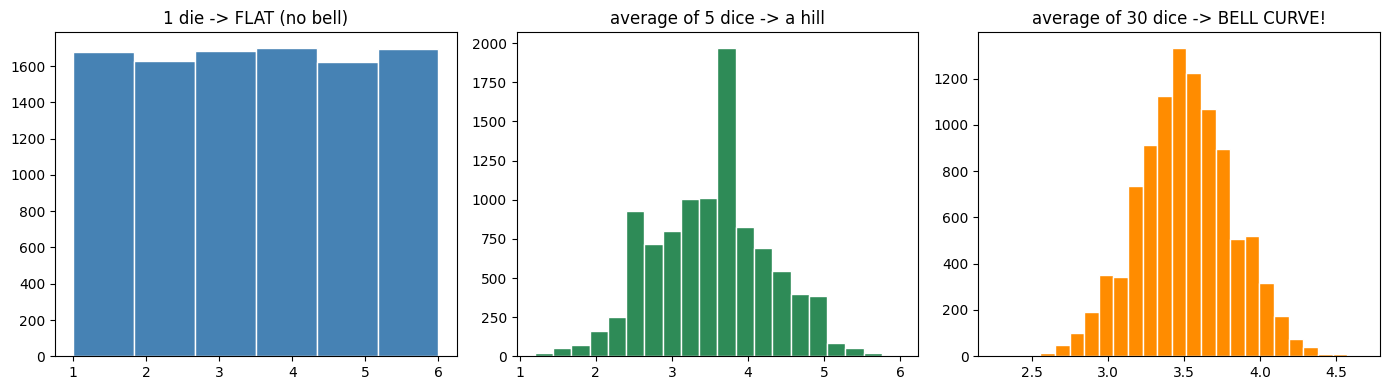

The original data was perfectly FLAT.
But averaging turns it into a bell curve -- and the more we average, the better it gets.


In [5]:
random.seed(2)

# CASE 1: single dice rolls (this should be FLAT)
one_die = []
for i in range(10000):
    one_die.append(random.randint(1, 6))

# CASE 2: average of 5 dice
averages_of_5 = []
for i in range(10000):
    total = 0
    for j in range(5):                  # roll 5 dice
        total = total + random.randint(1, 6)
    averages_of_5.append(total / 5)     # save their average

# CASE 3: average of 30 dice
averages_of_30 = []
for i in range(10000):
    total = 0
    for j in range(30):                 # roll 30 dice
        total = total + random.randint(1, 6)
    averages_of_30.append(total / 30)

print("done -- now let's look at the shapes")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))

ax[0].hist(one_die, bins=6, color="steelblue", edgecolor="white")
ax[0].set_title("1 die -> FLAT (no bell)")

ax[1].hist(averages_of_5, bins=20, color="seagreen", edgecolor="white")
ax[1].set_title("average of 5 dice -> a hill")

ax[2].hist(averages_of_30, bins=25, color="darkorange", edgecolor="white")
ax[2].set_title("average of 30 dice -> BELL CURVE!")

plt.tight_layout()
plt.show()

print("The original data was perfectly FLAT.")
print("But averaging turns it into a bell curve -- and the more we average, the better it gets.")